/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/yinzunyi/py3.9/lib/python3.9/site-packages/xarray/core/concat.py:527: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


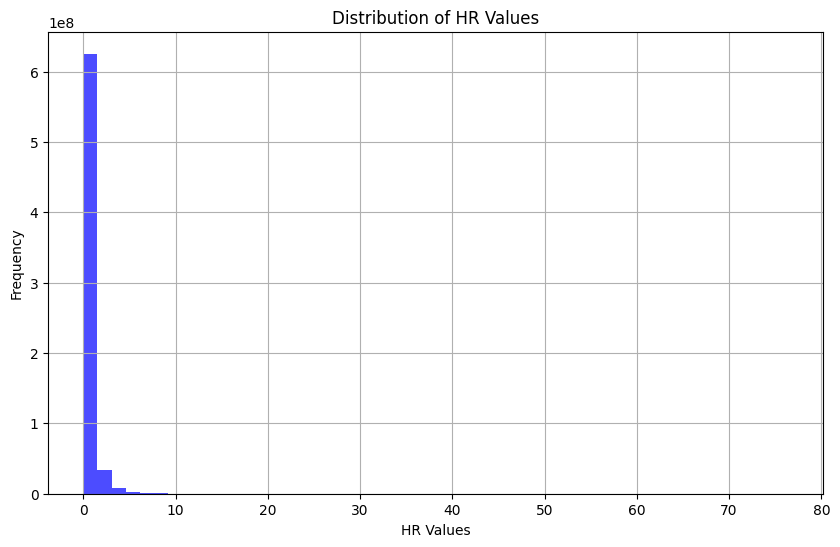

各区间的百分比：
-0.1 到 1.5: 92.67%
1.5 到 5: 6.77%
5 到 10: 0.51%
10 到 30: 0.05%
30 到 inf: 0.00%


In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# 加载数据集
ds = xr.open_mfdataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/deviation_correction/dataset/train/*.nc", combine='by_coords')


# 提取 'hr' 变量
hr_data = ds['hr_orig'].values.flatten()

# 计算指定区间的百分比
bins = [-0.1, 1.5, 5, 10, 30, np.inf]
counts, _ = np.histogram(hr_data, bins=bins)

# 总数据点数
total = hr_data.size

# 计算百分比
percentages = counts / total * 100

# 绘制数据分布图
plt.figure(figsize=(10, 6))
plt.hist(hr_data, bins=50, color='blue', alpha=0.7)
plt.title('Distribution of HR Values')
plt.xlabel('HR Values')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 打印各区间百分比
print("各区间的百分比：")
for i in range(len(bins)-1):
    print(f"{bins[i]} 到 {bins[i+1]}: {percentages[i]:.2f}%")
